# UNet Training for Optic Disc/Cup Segmentation

This notebook trains a UNet model for segmenting optic disc and cup in fundus images.

## 1. Setup and Imports

In [9]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train import train_model, plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Training Configuration

In [10]:
# Training hyperparameters
config = {
    'root_dir': str(project_root),
    'num_epochs': 50,
    'batch_size': 16,  # Increased from 4 to better utilize GPU memory
    'learning_rate': 1e-4,
    'image_size': 256,  # Reduced to 256 to allow larger batch size
    'base_channels': 64,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints'),
    'filter_incomplete': True
}

print("Training Configuration:")
print("=" * 50)
for key, value in config.items():
    print(f"{key:20s}: {value}")


Training Configuration:
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 50
batch_size          : 16
learning_rate       : 0.0001
image_size          : 256
base_channels       : 64
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints
filter_incomplete   : True


## 3. Train the Model

In [11]:
# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU cache cleared")
    print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"GPU memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")


GPU cache cleared
GPU memory allocated: 0.97 GB
GPU memory reserved: 1.19 GB


In [12]:
# Clear the dataset cache before training to ensure filter_incomplete works correctly
from data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Train the model
model, history = train_model(**config)


Using device: cuda

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
Model parameters: 31,043,651

Starting training for 50 epochs...

Epoch 1/50
--------------------------------------------------------------------------------
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
Model parameters: 31,043,651

Starting training for 50 epochs...

Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:02<00:00,  8.74it/s, loss=0.3933, iou_bg=0.7507, iou_disc=0.6695, iou_cup=0.6200]




Epoch 1 Summary:
  Train Loss: 0.5383 | Val Loss: 0.4034
  Train IoU - BG: 0.6383, Disc: 0.5797, Cup: 0.4581
  Val IoU   - BG: 0.7113, Disc: 0.6673, Cup: 0.6424
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.4034)

Epoch 2/50
--------------------------------------------------------------------------------
  ✓ Saved best model (val_loss: 0.4034)

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:02<00:00,  8.77it/s, loss=0.3524, iou_bg=0.7634, iou_disc=0.7016, iou_cup=0.6083]




Epoch 2 Summary:
  Train Loss: 0.3848 | Val Loss: 0.3285
  Train IoU - BG: 0.7196, Disc: 0.6809, Cup: 0.6164
  Val IoU   - BG: 0.7544, Disc: 0.7321, Cup: 0.6596
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3285)

Epoch 3/50
--------------------------------------------------------------------------------
  ✓ Saved best model (val_loss: 0.3285)

Epoch 3/50
--------------------------------------------------------------------------------


...


Epoch 48 Summary:
  Train Loss: 0.1779 | Val Loss: 0.1717
  Train IoU - BG: 0.8709, Disc: 0.8261, Cup: 0.7562
  Val IoU   - BG: 0.8675, Disc: 0.8376, Cup: 0.7521
  Learning Rate: 0.000100

Epoch 49/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:02<00:00,  8.70it/s, loss=0.1752, iou_bg=0.8712, iou_disc=0.8262, iou_cup=0.7496]



Epoch 49 Summary:
  Train Loss: 0.1778 | Val Loss: 0.1680
  Train IoU - BG: 0.8700, Disc: 0.8264, Cup: 0.7577
  Val IoU   - BG: 0.8663, Disc: 0.8400, Cup: 0.7682
  Learning Rate: 0.000100

Epoch 50/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:02<00:00,  8.69it/s, loss=0.1724, iou_bg=0.8730, iou_disc=0.8272, iou_cup=0.7535]




Epoch 50 Summary:
  Train Loss: 0.1745 | Val Loss: 0.1683
  Train IoU - BG: 0.8719, Disc: 0.8284, Cup: 0.7620
  Val IoU   - BG: 0.8681, Disc: 0.8385, Cup: 0.7678
  Learning Rate: 0.000100
  ✓ Saved checkpoint

Training completed!
Best validation loss: 0.1632
  ✓ Saved checkpoint

Training completed!
Best validation loss: 0.1632


## 4. Visualize Training Progress

Plot saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.png


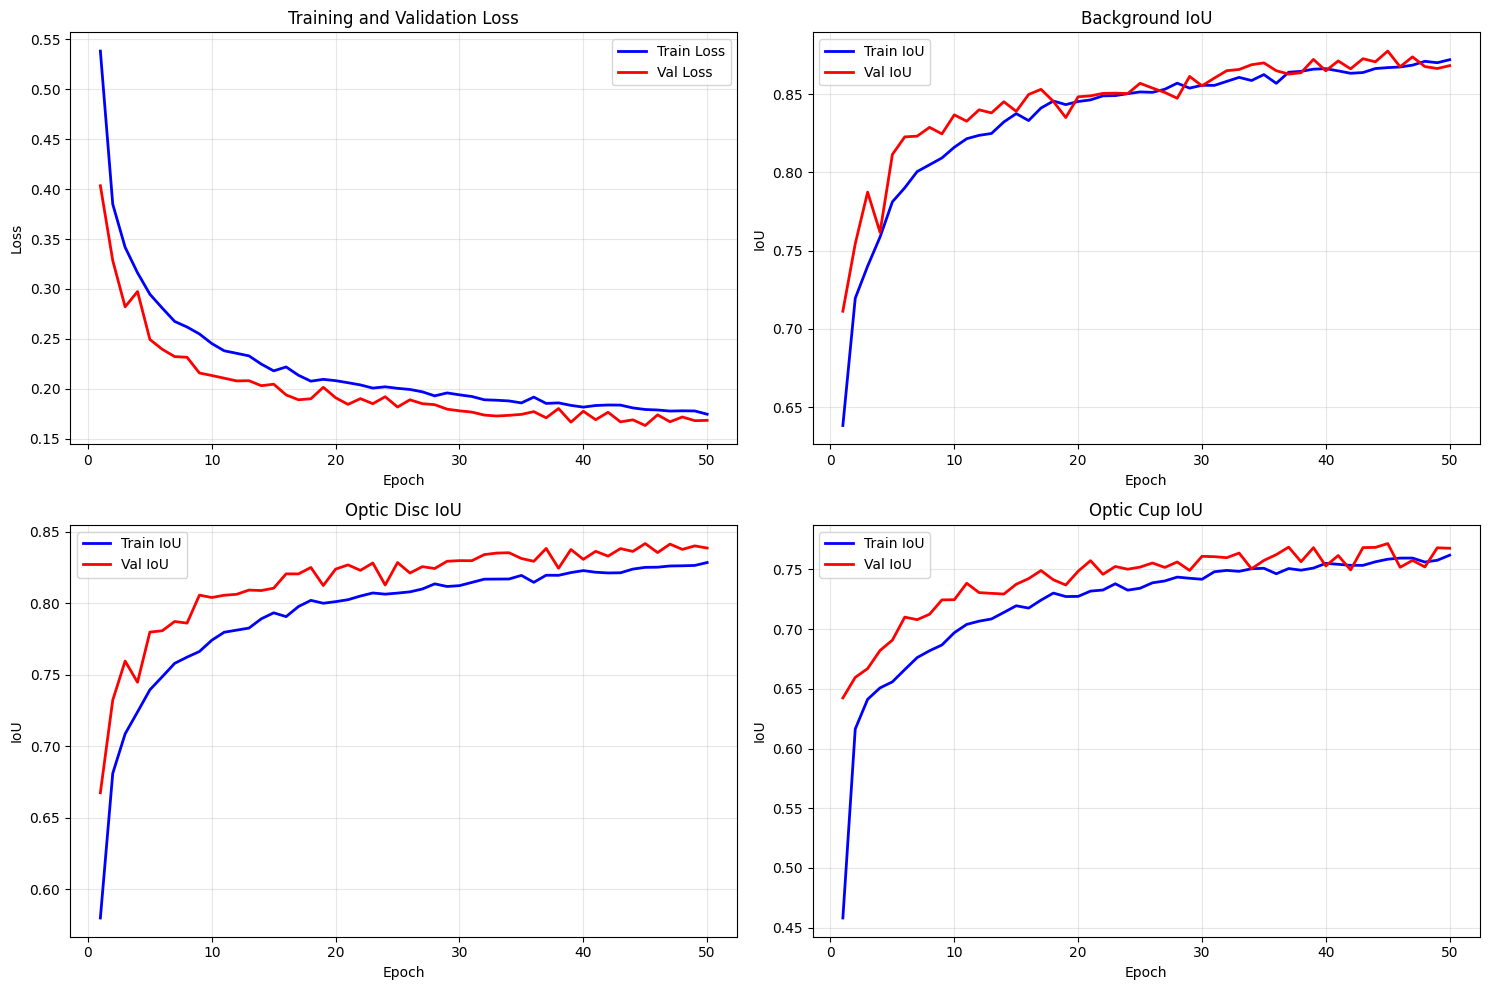

In [13]:
# Plot training history
fig = plot_training_history(
    history, 
    save_path=str(project_root / 'results' / 'training_history.png')
)
plt.show()

## 5. Print Final Metrics

In [14]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss:        {history['train_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['train_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['train_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['train_iou_cup'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss:        {history['val_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['val_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['val_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss:")
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)


FINAL TRAINING RESULTS

Total Epochs: 50

Final Training Metrics:
  Loss:        0.1745
  IoU (BG):    0.8719
  IoU (Disc):  0.8284
  IoU (Cup):   0.7620

Final Validation Metrics:
  Loss:        0.1683
  IoU (BG):    0.8681
  IoU (Disc):  0.8385
  IoU (Cup):   0.7678

Best Validation Loss:
  Epoch: 45
  Loss:  0.1632



## 6. Save Training History

In [15]:
import json

# Save history as JSON
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

history_path = results_dir / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved to: {history_path}")

Training history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.json


## 7. Visualize Predictions on Test Images

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396
Sample 78: IoU Disc=0.897, IoU Cup=0.769
Sample 277: IoU Disc=0.879, IoU Cup=0.785
Sample 250: IoU Disc=0.895, IoU Cup=0.912
Sample 55: IoU Disc=0.901, IoU Cup=0.868

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/predictions_visualization.png


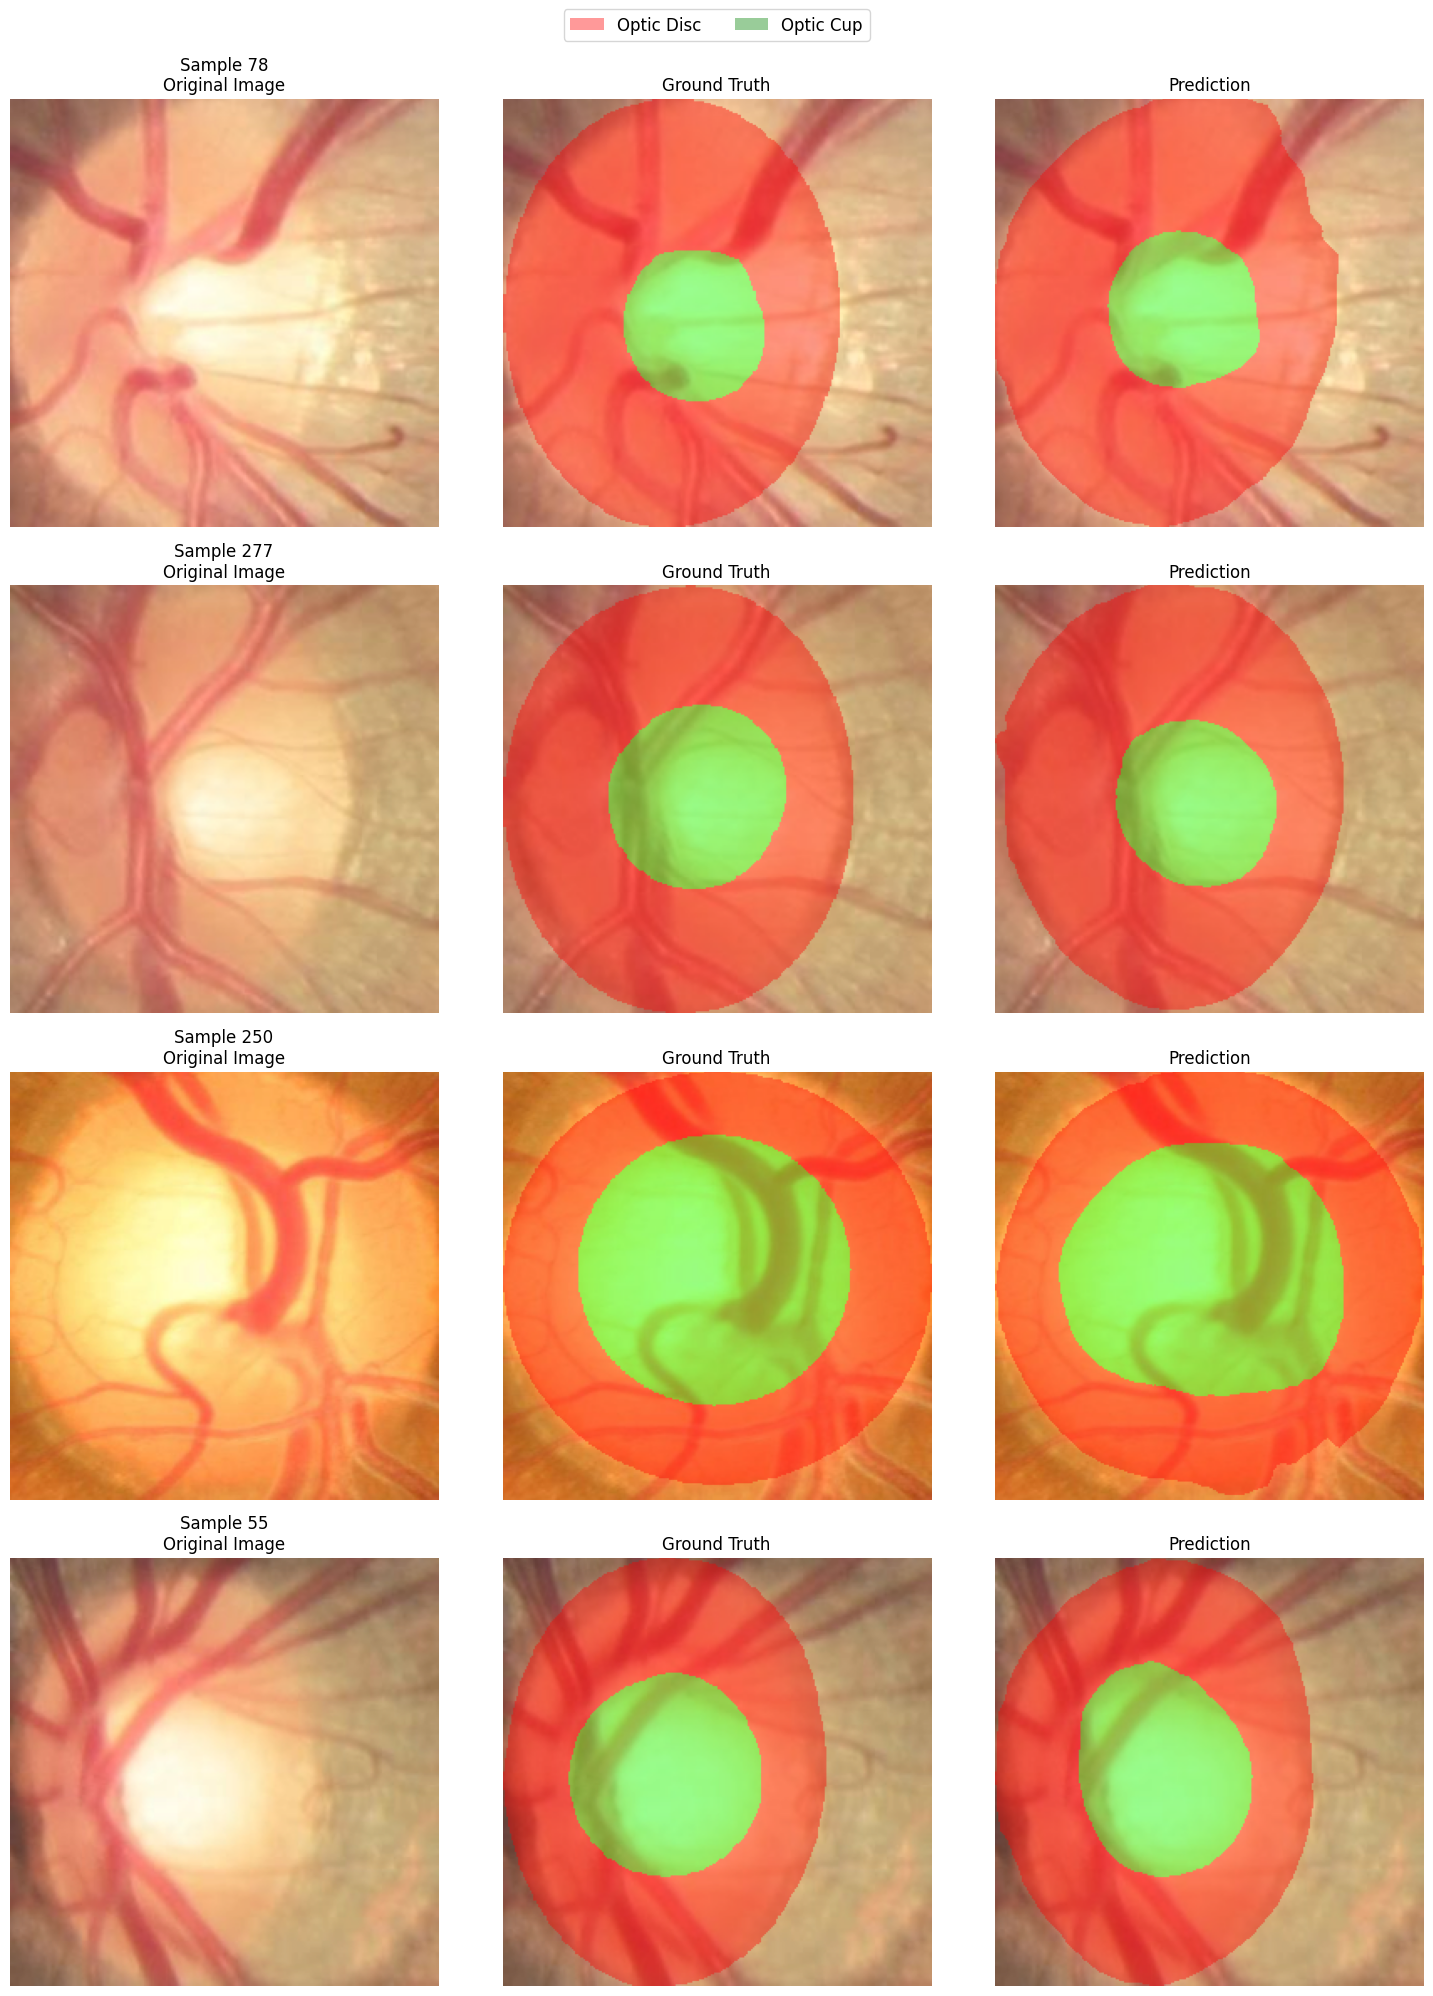

In [16]:
from utils.visualize_predictions import visualize_predictions

# Visualize predictions on test images
fig = visualize_predictions(
    checkpoint_path=str(project_root / 'checkpoints' / 'best_model.pth'),
    root_dir=str(project_root),
    num_samples=4,
    save_path=str(project_root / 'results' / 'predictions_visualization.png'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config['image_size'],
    seed=42
)
